>>> 正在生成: 各风格总分分布图 (Score Distribution)...


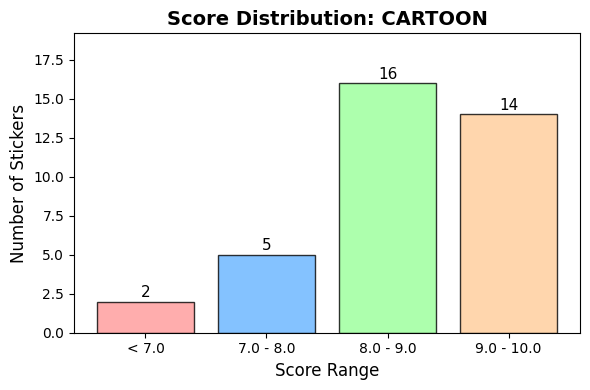

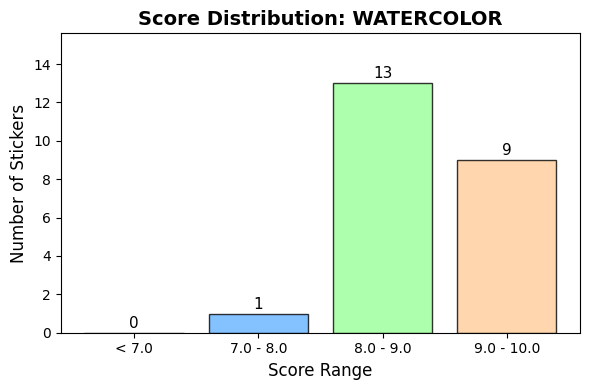

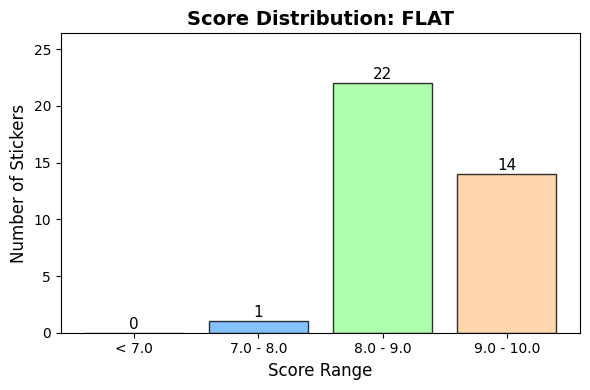


>>> 正在生成: 各风格各项维度平均分对比图 (Average Scores Comparison)...


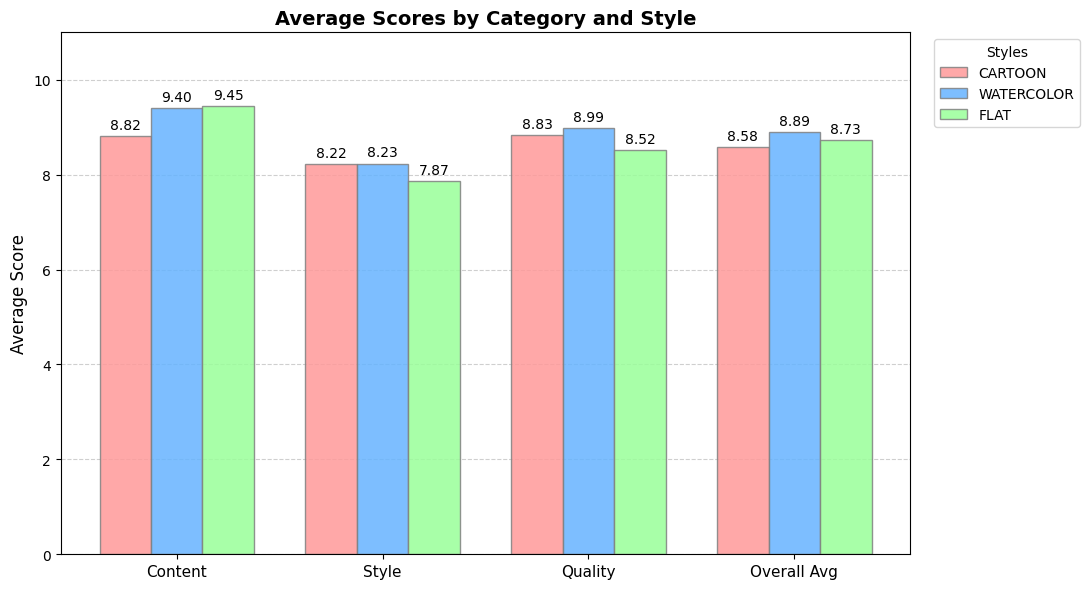


>>> 正在生成: 审核通过率饼图 (Pass vs Regenerate Ratio)...


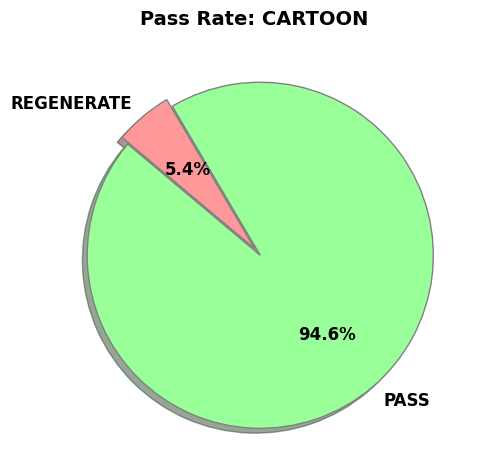

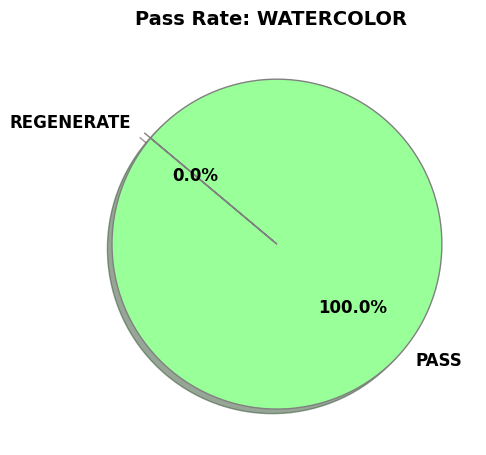

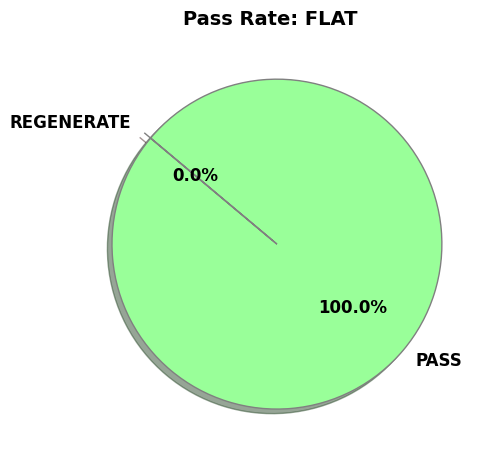

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 加载数据与颜色定义
# ==========================================
FILE_PATH = 'sticker_individual_scores.json'

with open(FILE_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

styles = list(data.keys())

# 定义统一调色板
# 0: 红(Regen/Cartoon), 1: 蓝(Watercolor), 2: 绿(Pass/Flat), 3: 橙
PALETTE = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
COLOR_PASS = PALETTE[2]      # 绿色
COLOR_REGEN = PALETTE[0]    # 红色

# ==========================================
# 2. 需求 ①：分数段分布图 (对齐原始配色)
# ==========================================
print(">>> 正在生成: 各风格总分分布图 (Score Distribution)...")
for style in styles:
    scores = [item['metrics']['sticker_average_score'] for item in data[style]]

    bins = {"< 7.0": 0, "7.0 - 8.0": 0, "8.0 - 9.0": 0, "9.0 - 10.0": 0}
    for s in scores:
        if s < 7.0: bins["< 7.0"] += 1
        elif 7.0 <= s < 8.0: bins["7.0 - 8.0"] += 1
        elif 8.0 <= s < 9.0: bins["8.0 - 9.0"] += 1
        else: bins["9.0 - 10.0"] += 1

    plt.figure(figsize=(6, 4))
    bars = plt.bar(bins.keys(), bins.values(), color=PALETTE, edgecolor='black', alpha=0.8)

    plt.title(f'Score Distribution: {style.upper()}', fontsize=14, fontweight='bold')
    plt.xlabel('Score Range', fontsize=12)
    plt.ylabel('Number of Stickers', fontsize=12)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom', fontsize=11)

    plt.ylim(0, max(bins.values()) * 1.2 if max(bins.values()) > 0 else 10)
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. 需求 ②：各项评分均值对比图 (颜色与风格对齐)
# ==========================================
print("\n>>> 正在生成: 各风格各项维度平均分对比图 (Average Scores Comparison)...")
metrics = ['content_score', 'style_score', 'quality_score', 'sticker_average_score']
labels = ['Content', 'Style', 'Quality', 'Overall Avg']

means = {style: [] for style in styles}
for style in styles:
    for metric in metrics:
        vals = [item['metrics'][metric] for item in data[style]]
        mean_val = np.mean(vals) if vals else 0
        means[style].append(mean_val)

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

# 循环时指定固定颜色
for i, style in enumerate(styles):
    offset = (i - len(styles)/2 + 0.5) * width
    # 使用 PALETTE 中的颜色：Cartoon-红, Watercolor-蓝, Flat-绿
    bars = ax.bar(x + offset, means[style], width, label=style.upper(),
                  color=PALETTE[i % len(PALETTE)], alpha=0.85, edgecolor='gray')
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)

ax.set_ylabel('Average Score', fontsize=12)
ax.set_title('Average Scores by Category and Style', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)

# 图例放在右侧外，不遮挡数据
ax.legend(title="Styles", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# ==========================================
# 4. 需求 ③：PASS/REGENERATE 比例饼图 (对齐 Pass-绿/Regen-红)
# ==========================================
print("\n>>> 正在生成: 审核通过率饼图 (Pass vs Regenerate Ratio)...")
for style in styles:
    statuses = [item['metrics']['status'] for item in data[style]]
    pass_count = statuses.count('PASS')
    regen_count = statuses.count('REGENERATE')

    sizes = [pass_count, regen_count]
    labels = ['PASS', 'REGENERATE']
    # 统一色调：PASS 对应调色板的绿色，REGENERATE 对应红色
    pie_colors = [COLOR_PASS, COLOR_REGEN]
    explode = (0.05, 0)

    if sum(sizes) == 0:
        continue

    plt.figure(figsize=(5, 5))
    plt.pie(sizes, explode=explode, labels=labels, colors=pie_colors,
            autopct='%1.1f%%', shadow=True, startangle=140,
            wedgeprops={'edgecolor': 'gray'},
            textprops={'fontsize': 12, 'fontweight': 'bold'})

    plt.title(f'Pass Rate: {style.upper()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

>>> 正在生成: 总分分布图 (Score Distribution)...


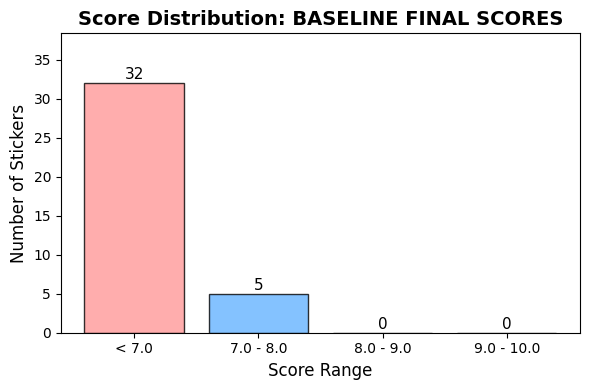


>>> 正在生成: 各维度平均分对比图 (Average Scores Comparison)...


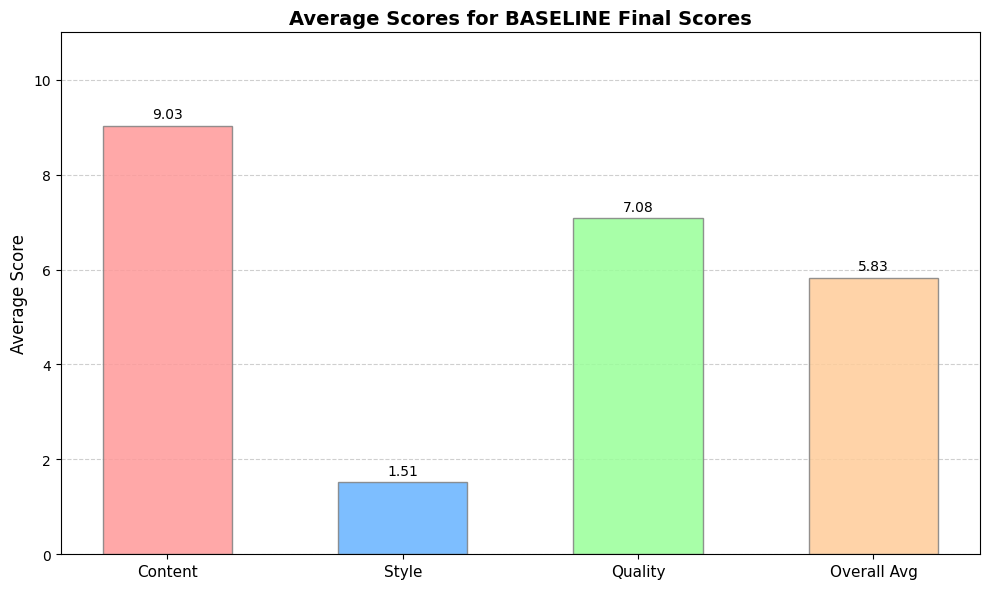


>>> 正在生成: 审核通过率饼图 (Pass vs Regenerate Ratio)...


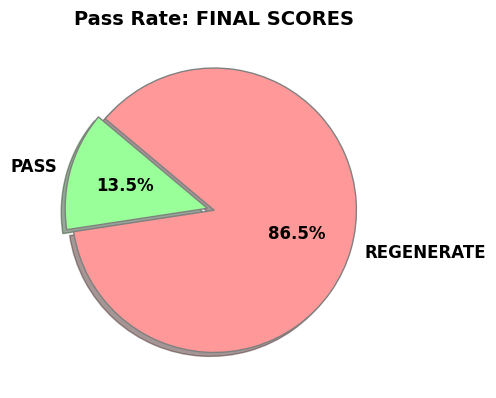

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 加载数据与颜色定义
# ==========================================
FILE_PATH = 'sticker_baseline_final_scores.json'

with open(FILE_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

# data 现在是一个 list，不再是按风格分组的 dict
items = data

# 定义统一调色板
# 0: 红(Regen/Cartoon), 1: 蓝(Watercolor), 2: 绿(Pass/Flat), 3: 橙
PALETTE = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
COLOR_PASS = PALETTE[2]      # 绿色
COLOR_REGEN = PALETTE[0]     # 红色

# ==========================================
# 2. 需求 ①：分数段分布图
# ==========================================
print(">>> 正在生成: 总分分布图 (Score Distribution)...")
scores = [item['metrics']['sticker_average_score'] for item in items]

bins = {"< 7.0": 0, "7.0 - 8.0": 0, "8.0 - 9.0": 0, "9.0 - 10.0": 0}
for s in scores:
    if s < 7.0:
        bins["< 7.0"] += 1
    elif 7.0 <= s < 8.0:
        bins["7.0 - 8.0"] += 1
    elif 8.0 <= s < 9.0:
        bins["8.0 - 9.0"] += 1
    else:
        bins["9.0 - 10.0"] += 1

plt.figure(figsize=(6, 4))
bars = plt.bar(bins.keys(), bins.values(), color=PALETTE, edgecolor='black', alpha=0.8)

plt.title('Score Distribution: BASELINE FINAL SCORES', fontsize=14, fontweight='bold')
plt.xlabel('Score Range', fontsize=12)
plt.ylabel('Number of Stickers', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom', fontsize=11)

plt.ylim(0, max(bins.values()) * 1.2 if max(bins.values()) > 0 else 10)
plt.tight_layout()
plt.show()

# ==========================================
# 3. 需求 ②：各项评分均值对比图
# ==========================================
print("\n>>> 正在生成: 各维度平均分对比图 (Average Scores Comparison)...")
metrics = ['content_score', 'style_score', 'quality_score', 'sticker_average_score']
labels = ['Content', 'Style', 'Quality', 'Overall Avg']

means = []
for metric in metrics:
    vals = [item['metrics'][metric] for item in items]
    mean_val = np.mean(vals) if vals else 0
    means.append(mean_val)

x = np.arange(len(metrics))
width = 0.55

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(x, means, width, color=PALETTE, alpha=0.85, edgecolor='gray')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)

ax.set_ylabel('Average Score', fontsize=12)
ax.set_title('Average Scores for BASELINE Final Scores', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)

ax.set_ylim(0, 11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# ==========================================
# 4. 需求 ③：PASS/REGENERATE 比例饼图
# ==========================================
print("\n>>> 正在生成: 审核通过率饼图 (Pass vs Regenerate Ratio)...")
statuses = [item['metrics']['status'] for item in items]
pass_count = statuses.count('PASS')
regen_count = statuses.count('REGENERATE')

sizes = [pass_count, regen_count]
labels = ['PASS', 'REGENERATE']
pie_colors = [COLOR_PASS, COLOR_REGEN]
explode = (0.05, 0)

if sum(sizes) > 0:
    plt.figure(figsize=(5, 5))
    plt.pie(
        sizes,
        explode=explode,
        labels=labels,
        colors=pie_colors,
        autopct='%1.1f%%',
        shadow=True,
        startangle=140,
        wedgeprops={'edgecolor': 'gray'},
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )

    plt.title('Pass Rate: FINAL SCORES', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

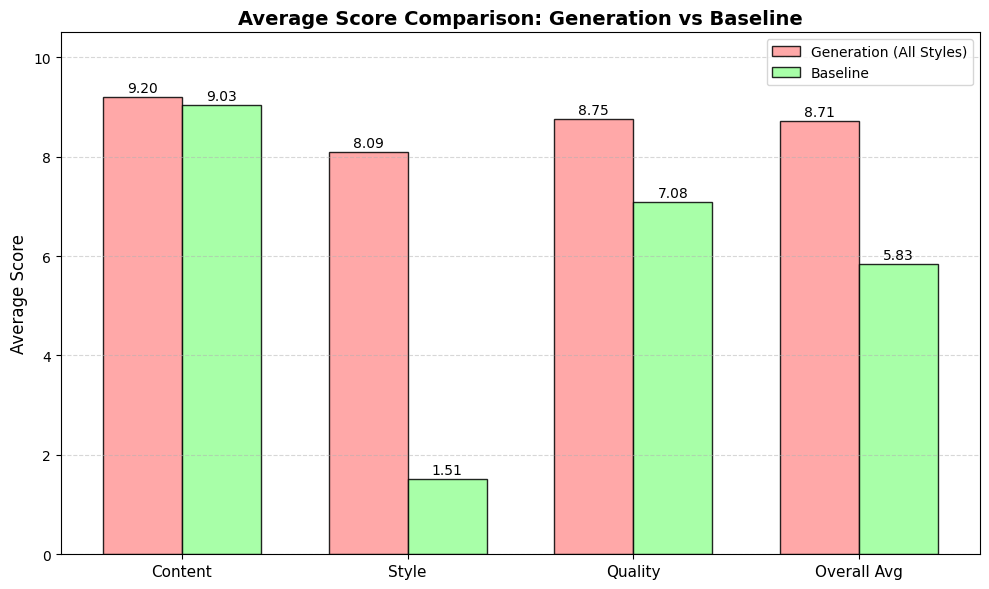

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 文件路径
# ==========================================
VIS_FILE = "sticker_individual_scores.json"          # 原 visualization 对应的结果
BASELINE_FILE = "sticker_baseline_final_scores.json"      # baseline 汇总后的结果

# ==========================================
# 2. 读取数据
# ==========================================
with open(VIS_FILE, "r", encoding="utf-8") as f:
    vis_data = json.load(f)

with open(BASELINE_FILE, "r", encoding="utf-8") as f:
    baseline_data = json.load(f)

# ==========================================
# 3. 计算 visualization 中“所有风格合并后”的平均值
#    兼容字典格式：{"cartoon":[...], "watercolor":[...], "flat":[...]}
# ==========================================
vis_items = []
if isinstance(vis_data, dict):
    for style_items in vis_data.values():
        vis_items.extend(style_items)
else:
    vis_items = vis_data

vis_content = [item["metrics"]["content_score"] for item in vis_items if "metrics" in item]
vis_style = [item["metrics"]["style_score"] for item in vis_items if "metrics" in item]
vis_quality = [item["metrics"]["quality_score"] for item in vis_items if "metrics" in item]
vis_overall = [item["metrics"]["sticker_average_score"] for item in vis_items if "metrics" in item]

vis_means = {
    "content_score": np.mean(vis_content) if vis_content else 0,
    "style_score": np.mean(vis_style) if vis_style else 0,
    "quality_score": np.mean(vis_quality) if vis_quality else 0,
    "sticker_average_score": np.mean(vis_overall) if vis_overall else 0,
}

# ==========================================
# 4. 计算 baseline 的平均值
# ==========================================
base_content = [item["metrics"]["content_score"] for item in baseline_data if "metrics" in item]
base_style = [item["metrics"]["style_score"] for item in baseline_data if "metrics" in item]
base_quality = [item["metrics"]["quality_score"] for item in baseline_data if "metrics" in item]
base_overall = [item["metrics"]["sticker_average_score"] for item in baseline_data if "metrics" in item]

baseline_means = {
    "content_score": np.mean(base_content) if base_content else 0,
    "style_score": np.mean(base_style) if base_style else 0,
    "quality_score": np.mean(base_quality) if base_quality else 0,
    "sticker_average_score": np.mean(base_overall) if base_overall else 0,
}

# ==========================================
# 5. 绘图：两组对比
# ==========================================
PALETTE = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

metrics = ["content_score", "style_score", "quality_score", "sticker_average_score"]
labels = ["Content", "Style", "Quality", "Overall Avg"]

vis_vals = [vis_means[m] for m in metrics]
base_vals = [baseline_means[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, vis_vals, width, label="Generation (All Styles)", color=PALETTE[0], edgecolor="black", alpha=0.85)
bars2 = plt.bar(x + width/2, base_vals, width, label="Baseline", color=PALETTE[2], edgecolor="black", alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.05,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, labels, fontsize=11)
plt.ylabel("Average Score", fontsize=12)
plt.title("Average Score Comparison: Generation vs Baseline", fontsize=14, fontweight="bold")
plt.ylim(0, 10.5)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()